# Imports

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import struct
import time
from decimal import Decimal

# Get weight values

In [2]:
# Allowed quantized weight values (no zero, range ±1..±7)
ALLOWED_WEIGHTS = np.array([-7, -6, -5, -4, -3, -2, -1, 1, 2, 3, 4, 5, 6, 7], dtype=np.int8)
NUM_CANDIDATES = len(ALLOWED_WEIGHTS)

# Input quantization scale (from your calibration – replace with actual S_x)
INPUT_SCALE = 1   # ← PUT YOUR ACTUAL S_x VALUE HERE

# The true weight element we are attacking (for demonstration)
true_weight = 5   # example: one of the allowed values

# Function Definitions

In [3]:
def float_to_binary_str(f):
    # Pack the float into 4 bytes (32-bit) using IEEE 754 standard
    [packed] = struct.unpack('!I', struct.pack('!f', f))
    # Convert the packed number to a binary string
    return f"{packed:032b}"

In [37]:
def HW_float32(f):
    # Get the binary representation of the 32-bit float
    binary_str = float_to_binary_str(f)
    # Count and return the number of '1' bits
    return binary_str.count('1')

def HW_int32(x):
    """Hamming weight of a 32-bit signed integer (for accumulator leakage)."""
    return bin(x & 0xFFFFFFFF).count('1')

In [5]:
#get one part of the binary representation
def getbyte(value, part):
    """Extract part of an int8 value.
    part = 0 : sign bit (0 or 1)
    part = 1 : full unsigned byte (0..255)
    part = 2 : lower 7 bits (0..127)
    """
    # Convert signed int8 to unsigned 8-bit representation
    u8 = value & 0xFF
    if part == 0:
        return (u8 >> 7) & 1
    elif part == 1:
        return u8
    elif part == 2:
        return u8 & 0x7F
    else:
        raise ValueError("Invalid part")

#### The values to be recovered

In [6]:
#true values of different parts of the weight
true_sign_bit = getbyte(true_weight,0)
true_exponent_bits = getbyte(true_weight,1)
true_byte_two = getbyte(true_weight,2)
true_byte_three = getbyte(true_weight,3)
true_byte_four = getbyte(true_weight,4)
true_value_index = list(ALLOWED_WEIGHTS).index(true_weight)

ValueError: Invalid part

In [7]:
print("sign bit = " + str(true_sign_bit) + ", exponent = " + str(true_exponent_bits) + ", first mantissa byte = " + str(true_byte_two) + ", second mantissa byte = " + str(true_byte_three) + ", last 7 bits = " + str(true_byte_four))

NameError: name 'true_byte_three' is not defined

In [8]:
def get_hypothetical_leakages(num_of_traces, inputs_q, weight_position):
    """
    inputs_q : array of shape (num_traces, 10) – already int8
    weight_position : index of the weight being attacked (0..9)
    """
    leakages = np.zeros((NUM_CANDIDATES, num_of_traces))
    for cand_idx, w in enumerate(ALLOWED_WEIGHTS):
        for trace_idx in range(num_of_traces):
            acc_contrib = int(w) * int(inputs_q[trace_idx, weight_position])
            leakages[cand_idx, trace_idx] = HW_int32(acc_contrib)
    return leakages

In [9]:
def CPA_attack(num_of_traces, inputs_q, total_time_sample, start_time_sample, trace_arr, weight_position):
    r_abs = np.zeros((NUM_CANDIDATES, total_time_sample))
    hypothetical_leakages = get_hypothetical_leakages(num_of_traces, inputs_q, weight_position)
    
    for t in range(total_time_sample):
        time_sample_index = t + start_time_sample
        if t % 100 == 0:
            print("calculating for time sample " + str(time_sample_index))
        for cand_idx in range(NUM_CANDIDATES):
            corr_coef = np.corrcoef(hypothetical_leakages[cand_idx], trace_arr[:, time_sample_index])[0][1]
            r_abs[cand_idx][t] = abs(corr_coef)
    return r_abs

In [10]:
def recover_byte(correlation_arr, byte_position, total_time_sample, weight_candidates=ALLOWED_WEIGHTS):
    # Determine number of possible byte values based on which part we're extracting
    if byte_position == 0:      # sign bit
        num_values = 2
    elif byte_position == 4:    # 7 magnitude bits
        num_values = 128
    else:                       # full byte or other byte positions
        num_values = 256
    
    # Initialize correlation matrix for each possible byte value
    correlations = np.zeros((num_values, total_time_sample))
    
    total_num_of_weight = len(weight_candidates)
    
    for weight_index in range(total_num_of_weight):
        weight = weight_candidates[weight_index]
        byte_value = getbyte(weight, byte_position)
        
        # For each time sample, keep the maximum correlation for this byte value
        for t in range(total_time_sample):
            if abs(correlation_arr[weight_index, t]) > abs(correlations[byte_value, t]):
                correlations[byte_value, t] = correlation_arr[weight_index, t]
    
    return correlations

In [11]:
def plot_correlations(correlation, value_index, total_time_sample, start_time_sample):
    x = []
    total_plots = len(correlation)
    
    for t in range(total_time_sample):
        x.append(t+start_time_sample)
    
    plt.plot(x,correlation[value_index], color="r")
    
    for i in range(total_plots):
        if i == value_index:
            continue
        else: 
            plt.plot(x,correlation[i], color="#808080")
    return

In [12]:
def savefile(foldername, filename, arr, total_time_sample, start_time_sample):
    f = open(foldername + "//" + filename + ".txt", "w")
    length = len(arr)#number of columns
    
    
    #first line
    f.write("x ")
    for i in range(length):
        f.write("y"+str(i)+" ")
    f.write("\n")
    
    for t in range(total_time_sample):#for each line
        f.write(str(t+start_time_sample)+" ")#first write down the time sample
        for j in range(length):
            f.write(str(arr[j][t])+" ")
        f.write("\n")
    f.close()
    return

In [13]:
def load_traces(num_of_traces, folder_name):
    trace_waves_arr = []
    inputs_arr = []

    # Read trace files
    for i in range(num_of_traces):
        with open(folder_name + '/trace_' + str(i) + '.txt') as f:
            line = f.read().strip()
            samples = [float(x) for x in line.split()]
            trace_waves_arr.append(samples)

    # Read inputs file (now space-separated integers)
    with open(folder_name + '/inputs.txt') as f:
        lines = f.read().splitlines()
        for line in lines:
            inputs = [int(x) for x in line.strip().split()]
            inputs_arr.append(inputs)

    trace_waves_arr = np.array(trace_waves_arr, dtype='f')
    inputs_arr = np.array(inputs_arr, dtype=np.int8)

    print("Loaded traces shape:", trace_waves_arr.shape)
    print("Loaded inputs shape:", inputs_arr.shape)
    return trace_waves_arr, inputs_arr 

In [14]:
#### Find the maximum values for correlations for first byte of mantissa
def find_max_first_byte(total_time_sample, start_time_sample, foldername, filename, cor):
    max_values = [0 for t in range(total_time_sample)]
    for t in range(total_time_sample):
        for ex in range(256):
            if ex == true_byte_two:
                continue
            else:
                if(cor[ex][t] > max_values[t]):
                    max_values[t]= cor[ex][t]
                
    #save the file
    f = open(foldername + "//" + filename + ".txt", "w")    
    
    #first line---
    f.write("x y\n")
    #other lines
    for t in range(total_time_sample):#for each line
        f.write(str(t+start_time_sample)+" " + str(max_values[t])+"\n")#first write down the time sample, then the correlation value
    f.close()
    return

# Attack on unprotected traces

In [15]:
traces, inputs_q = load_traces(num_of_traces=2000, folder_name="unprotected")

Loaded traces shape: (2000, 24430)
Loaded inputs shape: (2000, 10)


In [34]:
start = 6200
end = 8000
total = end - start

In [38]:
weight_pos = 0
r = CPA_attack(2000, inputs_q, total, start, traces, weight_pos)

# Find best candidate
best_idx = np.unravel_index(np.argmax(r), r.shape)[0]
recovered_weight = ALLOWED_WEIGHTS[best_idx]
print(f"Recovered weight: {recovered_weight}")

# To attack all 60 weights of Layer 1:
recovered_W1 = np.zeros((1, 10), dtype=int)   # 1 output neuron, 10 inputs

for in_ch in range(10):
    r = CPA_attack(2000, inputs_q, total, start, traces, in_ch)   # ← pass in_ch
    best_idx = np.unravel_index(np.argmax(r), r.shape)[0]
    recovered_W1[0, in_ch] = ALLOWED_WEIGHTS[best_idx]
    print(f"W1[0,{in_ch}] = {recovered_W1[0, in_ch]}")

calculating for time sample 6200
calculating for time sample 6300
calculating for time sample 6400
calculating for time sample 6500
calculating for time sample 6600
calculating for time sample 6700
calculating for time sample 6800
calculating for time sample 6900
calculating for time sample 7000
calculating for time sample 7100
calculating for time sample 7200
calculating for time sample 7300
calculating for time sample 7400
calculating for time sample 7500
calculating for time sample 7600
calculating for time sample 7700
calculating for time sample 7800
calculating for time sample 7900
Recovered weight: -7
calculating for time sample 6200
calculating for time sample 6300
calculating for time sample 6400
calculating for time sample 6500
calculating for time sample 6600
calculating for time sample 6700
calculating for time sample 6800
calculating for time sample 6900
calculating for time sample 7000
calculating for time sample 7100
calculating for time sample 7200
calculating for time s

#### Correlations for each weight value

In [33]:
plot_correlations(r,true_value_index, total, start)

NameError: name 'true_value_index' is not defined

#### Sign bit recovery

In [53]:
correlations_sign_bit = recover_byte(r, 0, total)

OverflowError: Python integer 255 out of bounds for int8

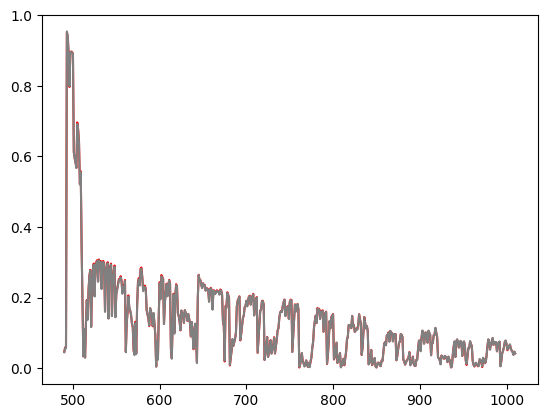

In [30]:
plot_correlations(correlations_sign_bit, true_sign_bit, total, start)

#### Exponent bits ecovery

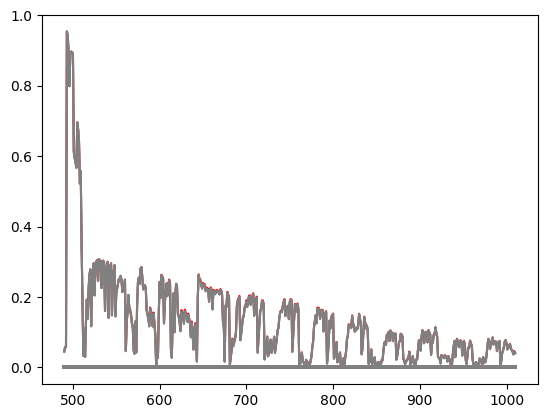

In [31]:
correlations_exponent_bits = recover_byte(r,1, total)
plot_correlations(correlations_exponent_bits, true_exponent_bits, total, start)

#### First byte of mantissa

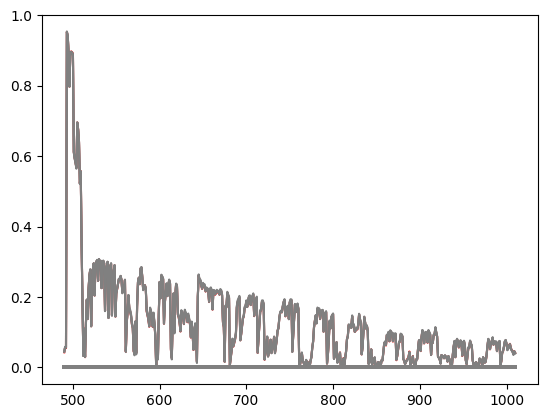

In [32]:
correlations_byte_two = recover_byte(r, 2, total)
plot_correlations(correlations_byte_two, true_byte_two, total, start)

#### Second byte of mantissa

In [33]:
correlations_byte_three = recover_byte(r, 3, total)

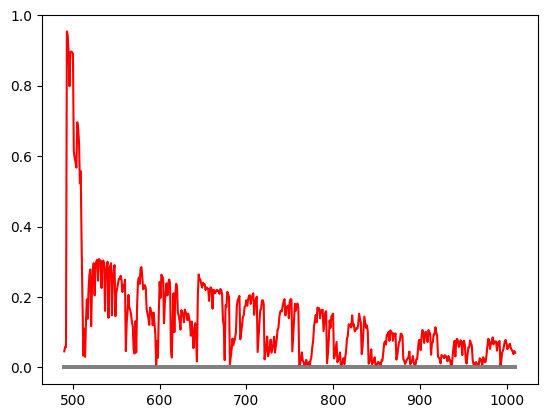

In [34]:
plot_correlations(correlations_byte_three, true_byte_three, total, start)

#### Last 7 bits recovery

In [35]:
correlations_byte_four = recover_byte(r, 4, total)

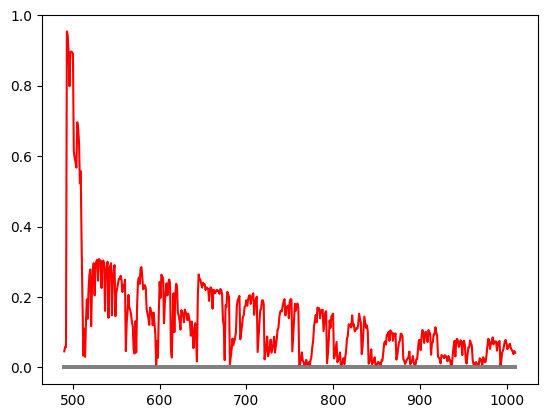

In [36]:
plot_correlations(correlations_byte_four, true_byte_four, total, start)

In [37]:
savefile("correlations", "signbit", correlations_sign_bit, total, start)
savefile("correlations", "exponentbits", correlations_exponent_bits, total, start)
savefile("correlations", "firstbyte", correlations_byte_two, total, start)
savefile("correlations", "secondbyte", correlations_byte_three, total, start)
savefile("correlations", "lastbits", correlations_byte_four, total, start)

FileNotFoundError: [Errno 2] No such file or directory: 'correlations//signbit.txt'

In [38]:
find_max_first_byte(total, start, "correlations", "firstbyte_max", correlations_byte_two)

FileNotFoundError: [Errno 2] No such file or directory: 'correlations//firstbyte_max.txt'

# Attack on protected traces

In [30]:
traces_pro, inputs_pro = load_traces(num_of_traces=10000, folder_name="protected")

In [43]:
start = 490
end_pro = 4301
total_pro = end_pro - start

In [44]:
r_pro = CPA_attack(num_of_traces=10000, inputs_arr=inputs_pro, total_time_sample=total_pro, start_time_sample=start, trace_arr=traces_pro)

calculating for time sample 490
calculating for time sample 590
calculating for time sample 690
calculating for time sample 790
calculating for time sample 890
calculating for time sample 990
calculating for time sample 1090
calculating for time sample 1190
calculating for time sample 1290
calculating for time sample 1390
calculating for time sample 1490
calculating for time sample 1590
calculating for time sample 1690
calculating for time sample 1790
calculating for time sample 1890
calculating for time sample 1990
calculating for time sample 2090
calculating for time sample 2190
calculating for time sample 2290
calculating for time sample 2390
calculating for time sample 2490
calculating for time sample 2590
calculating for time sample 2690
calculating for time sample 2790
calculating for time sample 2890
calculating for time sample 2990
calculating for time sample 3090
calculating for time sample 3190
calculating for time sample 3290
calculating for time sample 3390
calculating for 

#### Correlations for each weight value

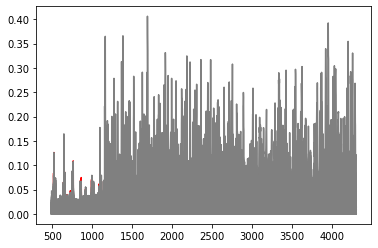

In [45]:
plot_correlations(r_pro,true_value_index, total_pro, start)

#### Sign bit recovery

In [46]:
correlations_sign_bit_pro = recover_byte(r_pro, 0, total_pro)

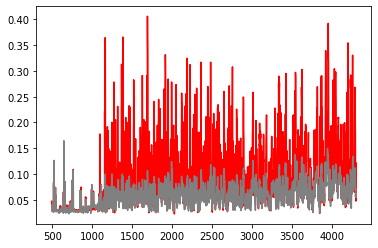

In [47]:
plot_correlations(correlations_sign_bit_pro, true_sign_bit, total_pro, start)

#### Exponent bits ecovery

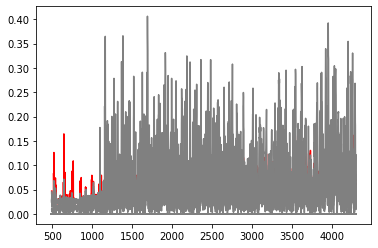

In [48]:
correlations_exponent_bits_pro = recover_byte(r_pro, 1, total_pro)
plot_correlations(correlations_exponent_bits_pro, true_exponent_bits, total_pro, start)

#### First byte of mantissa

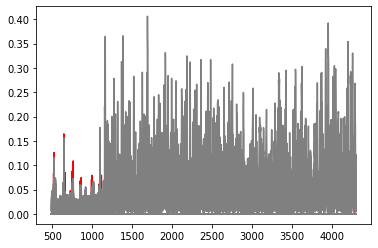

In [49]:
correlations_byte_two_pro = recover_byte(r_pro, 2, total_pro)
plot_correlations(correlations_byte_two_pro, true_byte_two, total_pro, start)

#### Second byte of mantissa

In [50]:
correlations_byte_three_pro = recover_byte(r_pro, 3, total_pro)

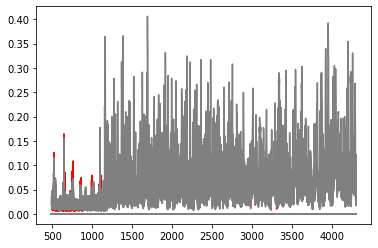

In [51]:
plot_correlations(correlations_byte_three_pro, true_byte_three, total_pro, start)

#### Last 7 bits recovery

In [52]:
correlations_byte_four_pro = recover_byte(r_pro, 4, total_pro)

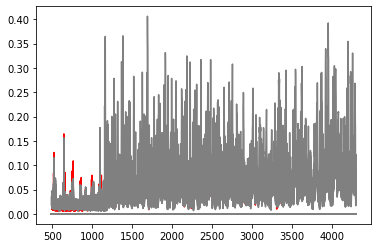

In [53]:
plot_correlations(correlations_byte_four_pro, true_byte_four, total_pro, start)

In [54]:
savefile("correlations-protected", "shuffled_signbit", correlations_sign_bit_pro, total_pro, start)
savefile("correlations-protected", "shuffled_exponentbits", correlations_exponent_bits_pro, total_pro, start)
savefile("correlations-protected", "shuffled_firstbyte", correlations_byte_two_pro, total_pro, start)
savefile("correlations-protected", "shuffled_secondbyte", correlations_byte_three_pro, total_pro, start)
savefile("correlations-protected", "shuffled_lastbits", correlations_byte_four_pro, total_pro, start)

In [55]:
find_max_first_byte(total_pro, start, "correlations-protected", "shuffled_firstbyte_max", correlations_byte_two_pro)

# Find all the possible values for each part of the binary representation

In [29]:
def print_bytes_for_all():
    all_bytes_values = [[] for i in range(4)]
    
    for i in range(4):
        for weight_value in weights_arr:
            all_bytes_values[0].append(getbyte(weight_value,1))#exponent bytes
            all_bytes_values[1].append(getbyte(weight_value,2))#first byte of mantissa
            all_bytes_values[2].append(getbyte(weight_value,3))#second byte of mantissa
            all_bytes_values[3].append(getbyte(weight_value,4))#last 7 bits
    
    distinct_values = [[] for i in range(4)]
    value_frequency = [[] for i in range(4)]
    num_of_distinct_values = [0 for i in range(4)]
    for i in range(4):
        values, counts = np.unique(all_bytes_values[i], return_counts=True)
        distinct_values[i] = values
        value_frequency[i] = counts
        num_of_distinct_values[i] = len(distinct_values[i])
    
    bytename = ["exponent bits", "first byte of mantissa", "second byte of mantissa", "last 7 bits"]
    for i in range(4):
        print("\nThere are " + str(num_of_distinct_values[i]) + " distinct " + bytename[i])
        for j in range(num_of_distinct_values[i]):
            print(str(distinct_values[i][j]) + ", ", end="")
        print("\nwith frequencies:")
        print(value_frequency[i])
    return

print_bytes_for_all()


There are 10 distinct exponent bits
0, 120, 121, 122, 123, 124, 125, 126, 127, 128, 
with frequencies:
[  4   8  16  24  48  96 200 400 800   8]

There are 100 distinct first byte of mantissa
0, 2, 5, 7, 10, 12, 15, 17, 20, 23, 25, 28, 30, 33, 35, 38, 40, 43, 46, 48, 51, 53, 56, 58, 61, 64, 66, 69, 71, 74, 76, 79, 81, 84, 87, 89, 92, 94, 97, 99, 102, 104, 107, 110, 112, 115, 117, 120, 122, 125, 128, 130, 133, 135, 138, 140, 143, 145, 148, 151, 153, 156, 158, 161, 163, 166, 168, 171, 174, 176, 179, 181, 184, 186, 189, 192, 194, 197, 199, 202, 204, 207, 209, 212, 215, 217, 220, 222, 225, 227, 230, 232, 235, 238, 240, 243, 245, 248, 250, 253, 
with frequencies:
[36  8 16  8 32  8 16  8 24  8 16  8 40  8 16  8 24  8 16  8 32  8 16  8
 24  8 16  8 64  8 16  8 24  8 16  8 32  8 16  8 24  8 16  8 40  8 16  8
 24  8 16  8 32  8 16  8 24  8 16  8 48  8 16  8 24  8 16  8 32  8 16  8
 24  8 16  8 40  8 16  8 24  8 16  8 32  8 16  8 24  8 16  8 56  8 16  8
 24  8 16  8]

There are 25 distinct sec